In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

import importlib
import track

# Development helper: uncomment after editing track.py.
# importlib.reload(track)

# Load Snapshot

加载单日 OFES NP30 快照，Arakawa-C 交错网格自动插值到示踪物格点，速度 cm/s → m/s。

In [2]:
snap = track.load_ofes_snapshot('2003-01-01', depth_max=1100)
print(list(snap.keys()))
print(f"do2: {snap['do2'].shape}, u: {snap['u'].shape}")

['date', 'lat', 'lon', 'lev', 'do2', 'temp', 'salinity', 'u', 'v', 'w']
do2: (75, 600, 900), u: (75, 600, 900)


# Quick-Look Horizontal Slice

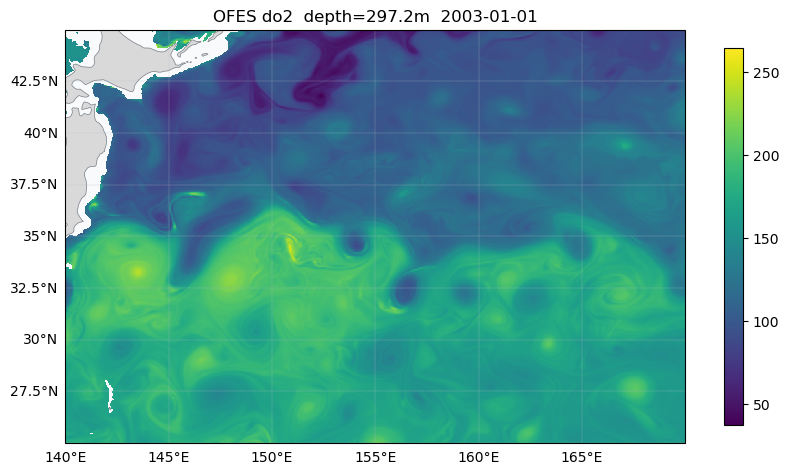

In [3]:
track.plot_ofes_snapshot_quick(snap, variable='do2', depth=300.0)

# Vertical Profile Extraction

从快照中双线性插值提取虚拟剖面，列名与 Argo 对齐（Depth / do2 / temp / salinity）。

In [4]:
prof = track.extract_ofes_profile_interp(snap, lon=146.5, lat=37.0,
                                         variables=['do2', 'temp', 'salinity'])
prof.head(10)

,Depth,do2,temp,salinity
0,2.5,265.695801,21.071682,34.898403
1,7.5,265.695496,21.072376,34.898384
2,12.5,265.694916,21.072931,34.898361
3,17.5,265.683228,21.073086,34.898293
4,22.5,265.371704,21.062325,34.897091
5,27.5,264.936768,21.044788,34.895542
6,32.5,264.751251,21.034613,34.894691
7,37.5,264.062195,20.993803,34.891983
8,42.5,263.461060,20.935518,34.888592
9,47.5,263.073700,20.896553,34.886337


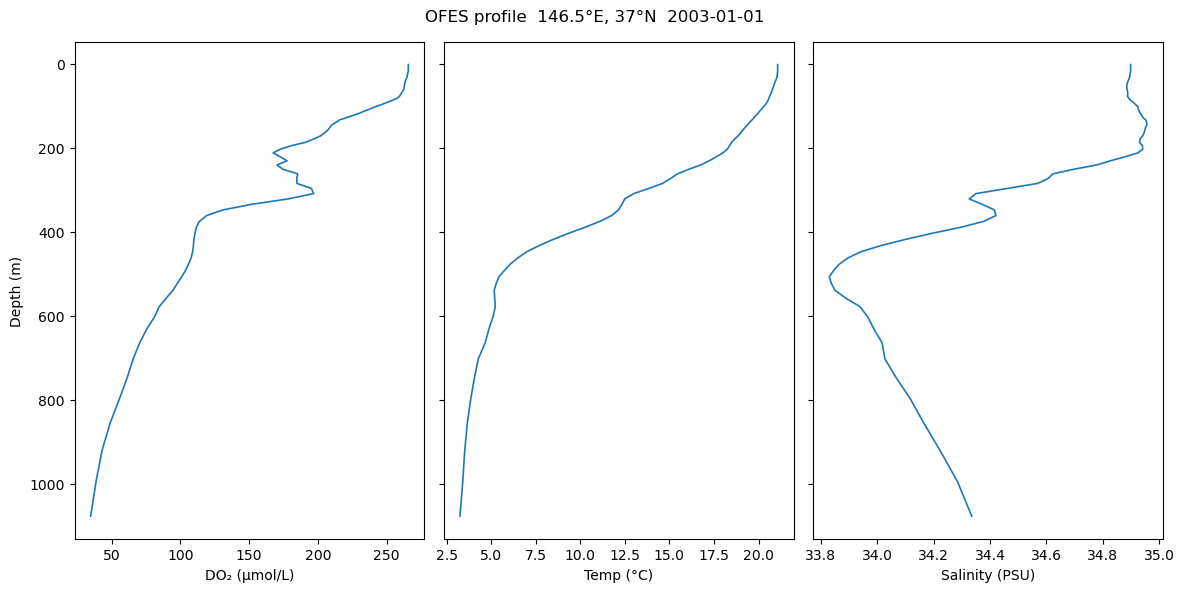

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
for ax, var, label in zip(axes, ['do2', 'temp', 'salinity'],
                          ['DO₂ (μmol/L)', 'Temp (°C)', 'Salinity (PSU)']):
    ax.plot(prof[var], prof['Depth'], linewidth=1.2)
    ax.set_xlabel(label)
    ax.invert_yaxis()
axes[0].set_ylabel('Depth (m)')
fig.suptitle(f"OFES profile  146.5°E, 37°N  {snap['date'].strftime('%Y-%m-%d')}")
fig.tight_layout()

# δDO Detection on OFES

复用观测 pipeline 的 `calculate_delta_do` 在 OFES 虚拟剖面上检测异常。

In [6]:
det_cfg = track.make_detection_config('do')

result = track.detect_ofes_delta_do(snap, lon=146.5, lat=37.0,
                                    detection_config=det_cfg)
result

,Profile_number,depth,delta_do,delta_salinity,delta_temperature,do_value,salinity_value,temperature_value,detection_method,primary_metric,primary_value,anomaly_score,delta_aou,Year,Month,Day,Longitude,Latitude
0,0,309.440887,58.242416,-0.204561,-0.618871,196.853485,34.35038,12.999263,do,delta_do,58.242416,58.242416,-56.565397,2003,1,1,146.5,37.0


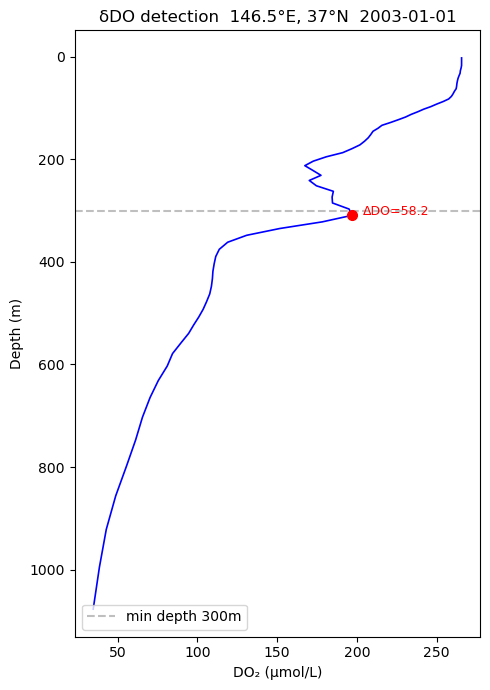

In [7]:
det_prof = track.extract_ofes_profile_interp(snap, lon=146.5, lat=37.0,
                                             variables=['do2'])
fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(det_prof['do2'], det_prof['Depth'], 'b-', linewidth=1.2)
ax.axhline(det_cfg.anomaly_min_depth, color='gray', ls='--', alpha=0.5,
           label=f'min depth {det_cfg.anomaly_min_depth:.0f}m')
for _, row in result.iterrows():
    ax.plot(row['do_value'], row['depth'], 'ro', ms=7)
    ax.annotate(f"ΔDO={row['delta_do']:.1f}", (row['do_value'], row['depth']),
                textcoords='offset points', xytext=(8, 0), color='red', fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('DO₂ (μmol/L)')
ax.set_ylabel('Depth (m)')
ax.set_title(f"δDO detection  146.5°E, 37°N  {snap['date'].strftime('%Y-%m-%d')}")
ax.legend(loc='lower left')
fig.tight_layout()

# Particle Advection

离线 RK4 粒子追踪（正向/反向），用两天快照验证。

In [8]:
snap2 = track.load_ofes_snapshot('2003-01-02', variables=['u', 'v', 'w'],
                                 depth_max=1100)

# 从检测到的异常点 + 同深度周围对照点释放粒子
anom_depth = result.iloc[0]['depth']
anom_lat = result.iloc[0]['Latitude']
anom_lon = result.iloc[0]['Longitude']

# 异常点 + 沿纬度±1°/±2° + 沿经度±1°/±2° 共 9 个点
offsets = [
    (0, 0),
    (0, -2), (0, -1), (0, +1), (0, +2),
    (-2, 0), (-1, 0), (+1, 0), (+2, 0),
]
particles = np.array([[anom_depth, anom_lat + dlat, anom_lon + dlon]
                       for dlat, dlon in offsets])
labels = [f"({dlat:+d},{dlon:+d})" if (dlat, dlon) != (0, 0) else "anomaly"
          for dlat, dlon in offsets]

traj_bwd = track.advect_ofes_particles([snap, snap2], particles, backward=True)

print(f"Release depth: {anom_depth:.0f}m | backward 1 day")
for i, lbl in enumerate(labels):
    d = traj_bwd[-1][i] - traj_bwd[0][i]
    km = np.sqrt((d[1]*111.32)**2 + (d[2]*111.32*np.cos(np.radians(particles[i,1])))**2)
    print(f"  {lbl:>12s}: Δlat={d[1]:+.4f}° Δlon={d[2]:+.4f}° Δdep={d[0]:+.1f}m  ~{km:.0f}km")

Release depth: 309m | backward 1 day
       anomaly: Δlat=-0.0019° Δlon=-0.5829° Δdep=+19.8m  ~52km
       (+0,-2): Δlat=+0.0371° Δlon=-0.0371° Δdep=-8.4m  ~5km
       (+0,-1): Δlat=-0.4732° Δlon=-0.2834° Δdep=+9.0m  ~58km
       (+0,+1): Δlat=+0.0108° Δlon=-0.2229° Δdep=+5.5m  ~20km
       (+0,+2): Δlat=-0.0638° Δlon=+0.3198° Δdep=-20.5m  ~29km
       (-2,+0): Δlat=-0.0944° Δlon=-0.0674° Δdep=-17.7m  ~12km
       (-1,+0): Δlat=+0.2278° Δlon=+0.4595° Δdep=+0.5m  ~49km
       (+1,+0): Δlat=-0.1072° Δlon=-0.1653° Δdep=-4.2m  ~19km
       (+2,+0): Δlat=-0.0770° Δlon=-0.0044° Δdep=-8.9m  ~9km


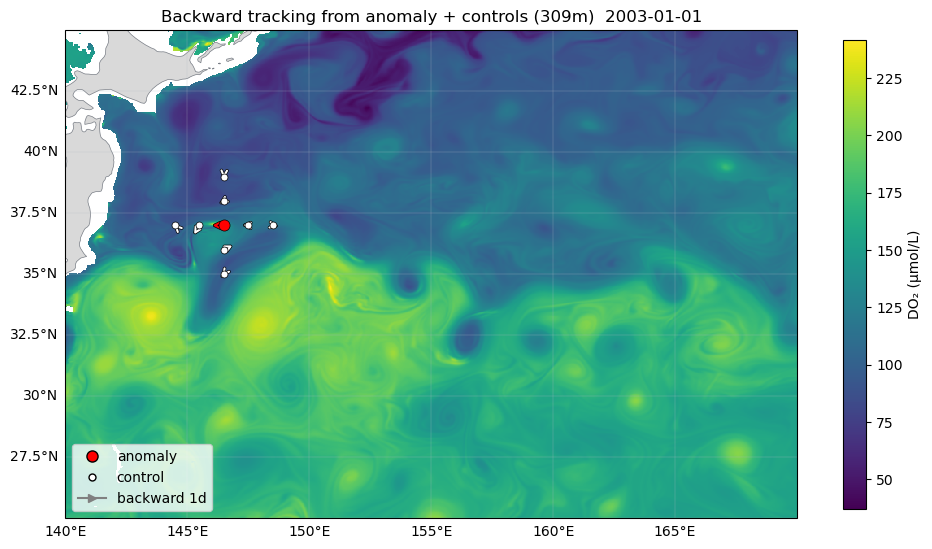

In [9]:
bc = track._BASEMAP_COLORS
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})
k = int(np.argmin(np.abs(snap['lev'] - anom_depth)))
im = ax.pcolormesh(snap['lon'], snap['lat'], snap['do2'][k],
                   transform=ccrs.PlateCarree(), cmap='viridis', shading='auto')
ax.add_feature(cfeature.LAND, facecolor=bc['land'], edgecolor=bc['coastline'],
               linewidth=0.5, zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color=bc['grid'], alpha=0.6)
gl.top_labels = False
gl.right_labels = False
fig.colorbar(im, ax=ax, shrink=0.7, label='DO₂ (μmol/L)')

p0, p1 = traj_bwd[0], traj_bwd[-1]
for i in range(len(particles)):
    color = 'red' if labels[i] == 'anomaly' else 'white'
    ms = 8 if labels[i] == 'anomaly' else 5
    ax.plot(p0[i, 2], p0[i, 1], 'o', color=color, ms=ms,
            markeredgecolor='black', markeredgewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=4)
    ax.annotate('', xy=(p1[i, 2], p1[i, 1]), xytext=(p0[i, 2], p0[i, 1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                path_effects=[patheffects.withStroke(linewidth=2.5, foreground='black')]),
                transform=ccrs.PlateCarree())

ax.plot([], [], 'ro', ms=8, markeredgecolor='black', label='anomaly')
ax.plot([], [], 'o', color='white', ms=5, markeredgecolor='black', label='control')
ax.plot([], [], '->', color='gray', label='backward 1d')
ax.legend(loc='lower left')

ax.set_title(f"Backward tracking from anomaly + controls ({anom_depth:.0f}m)  {snap['date'].strftime('%Y-%m-%d')}")
fig.tight_layout()